### Imports and Configuration

In [1]:
# Libraries

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sentence_transformers import SentenceTransformer
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics.pairwise import cosine_similarity
from urllib.parse import urlparse
import pickle
from tqdm.notebook import tqdm
from scipy.stats import rankdata
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Imported")


Libraries Imported


In [ ]:
# CONFIGURATION

CONFIG = {
    "dataset_path": "../Dataset/r6.2/",
    "processed_file": "../DatasetsProcessed/data_exfiltration_content_dataset_updated.csv",
    "agent1_path": "../SavedModels/v6_agent1_cae.pth",
    "agent2_path": "../SavedModels/v6_agent2_centroid.npy",
    "agent3_path": "../SavedModels/v6_agent3_baselines.pkl",
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu")
}

print(f"Running on device: {CONFIG['device']}")
print("Configuration loaded")

Running on device: cuda
Configuration loaded


### Data Loading Funtion

In [3]:
def load_cert_data(path):
    data = {}
    # List of expected files in the CERT r6.2 dataset directory
    files = ['insiders.csv', 'logon.csv', 'device.csv', 'file.csv', 'email.csv', 'http.csv']
    
    print("Loading datasets...")
    for f in tqdm(files):
        file_path = os.path.join(path, f)
        if os.path.exists(file_path):
            df = pd.read_csv(file_path)
            # Clean column namess
            df.columns = [c.strip() for c in df.columns]
            
            # Parse Dates
            date_cols = ['date'] if 'date' in df.columns else ['start', 'end']
            for dc in date_cols:
                if dc in df.columns:
                    df[dc] = pd.to_datetime(df[dc], format='%m/%d/%Y %H:%M:%S', errors='coerce')
            
            key = f.split('.')[0]
            data[key] = df
        else:
            print(f"Warning: {f} not found in {path}")
    return data

### Session Creation and Feature Extraction Function

In [4]:
def create_sessions_and_features(data):
    print("Processing Sessions and Extracting Features...")
    
    

    logon_df = data['logon'].sort_values(['user', 'date'])
    email_df = data['email'].sort_values('date')
    http_df = data['http'].sort_values('date')
    file_df = data['file'].sort_values('date')
    device_df = data['device'].sort_values('date')
    insiders_df = data['insiders']
    
    # Pre-indexing for speed
    email_df = email_df.set_index('date').sort_index()
    http_df = http_df.set_index('date').sort_index()
    file_df = file_df.set_index('date').sort_index()
    device_df = device_df.set_index('date').sort_index()
    
    # --- 1. PRE-PROCESS THREATS (The "Generic" but Optimized Approach) ---
    # We create a dictionary for O(1) lookup speed.
    # We FILTER for Scenarios 1, 2, 4, 5 (Data Exfiltration Scope)
    # Scenario 3 is usually IT Sabotage/Keylogging, so we skip it.
    
    # Ensure 'scenario' column exists and filter
    target_scenarios = [1, 2, 4, 5]
    if 'scenario' in insiders_df.columns:
        threats_filtered = insiders_df[insiders_df['scenario'].isin(target_scenarios)]
    else:
        threats_filtered = insiders_df # Fallback if column missing

    malicious_map = {}
    for _, row in threats_filtered.iterrows():
        u = row['user']
        if u not in malicious_map: malicious_map[u] = []
        malicious_map[u].append((row['start'], row['end']))
    
    print(f"Loaded {len(malicious_map)} malicious users for Scenarios {target_scenarios}")

    sessions = []
    
    # Group by user to build sessions
    grouped_logon = logon_df.groupby('user')
    
    for user, group in tqdm(grouped_logon, desc="User Processing"):
        group = group.reset_index(drop=True)
        
        # Iterate through logon activities
        i = 0
        while i < len(group):
            if group.loc[i, 'activity'] == 'Logon':
                start_time = group.loc[i, 'date']
#                session_id = group.loc[i, 'id']
                
                # Find corresponding Logoff
                end_time = None
                j = i + 1
                while j < len(group):
                    if group.loc[j, 'activity'] == 'Logoff':
                        end_time = group.loc[j, 'date']
                        i = j # Skip to this logoff
                        break
                    elif group.loc[j, 'activity'] == 'Logon':
                        # New session started without logoff, assume close at new start or max 12h
                        end_time = group.loc[j, 'date']
                        i = j - 1 # Process this new logon next iteration
                        break
                    j += 1
                
                if end_time is None:
                    # If no logoff found, assume 8 hours duration
                    end_time = start_time + pd.Timedelta(hours=8)
                    i = len(group) # End of user logs
                
                # === FEATURE EXTRACTION FOR THIS SESSION ===
                
                # Helper to filter by user within the time slice
                def get_activity(df, u, s, e):
                    try:
                        slice_df = df[s:e]
                        return slice_df[slice_df['user'] == u]
                    except KeyError:
                        return pd.DataFrame(columns=df.columns)

                sess_email = get_activity(email_df, user, start_time, end_time)
                sess_http = get_activity(http_df, user, start_time, end_time)
                sess_file = get_activity(file_df, user, start_time, end_time)
                sess_device = get_activity(device_df, user, start_time, end_time)
                
                # -- Numerical Features (Agent 1) --
                duration = (end_time - start_time).total_seconds()
                
                # Exfiltration Indicators
                # 1. After Hours (7pm-7am or Weekend)
                is_weekend = 1 if start_time.weekday() >= 5 else 0
                is_after_hour = 1 if (start_time.hour >= 19 or start_time.hour < 7) else 0
                
                # 2. Email Exfiltration

                INTERNAL_DOMAIN = "dtaa.com"

                ext_emails = sess_email[~sess_email['to'].str.contains(INTERNAL_DOMAIN, na=False)]
                n_ext_emails = len(ext_emails)
                n_attachments = sess_email['attachments'].astype(str).apply(lambda x: 0 if x == 'nan' or x=='' else len(x.split(';'))).sum()
                total_email_size = sess_email['size'].sum()
                
                # 3. HTTP Exfiltration (Cloud Storage)
                cloud_keywords = ['dropbox', 'drive.google', 'mega', 'box.com', 'onedrive', 'wikileaks', 'pastebin']
                cloud_uploads = 0
                if not sess_http.empty:
                    cloud_uploads = sess_http['url'].apply(lambda x: 1 if any(k in str(x).lower() for k in cloud_keywords) else 0).sum()
                
                # 4. Device/File Exfiltration
                n_usb_connects = len(sess_device[sess_device['activity'].str.contains('Connect', case=False, na=False)])
                n_file_copies = len(sess_file)
                n_file_to_usb = 0
                if 'to_removable_media' in sess_file.columns:
                     n_file_to_usb = sess_file['to_removable_media'].astype(str).str.contains('True', case=False).sum()

                # -- Textual Data (For Agent 2) --
                # Extract specific content columns
                email_content_text = " ".join(sess_email['content'].dropna().astype(str).tolist()) if not sess_email.empty else ""
                http_url_text = " ".join(sess_http['url'].dropna().astype(str).tolist()) if not sess_http.empty else ""
                http_content_text = " ".join(sess_http['content'].dropna().astype(str).tolist()) if not sess_http.empty else ""
                file_names_text = " ".join(sess_file['filename'].dropna().astype(str).tolist()) if not sess_file.empty else ""
                file_content_text = " ".join(sess_file['content'].dropna().astype(str).tolist()) if not sess_file.empty else ""
                
#               --- 2. FAST LABELING CHECK ---
                label = 0
                if user in malicious_map:
                    for t_start, t_end in malicious_map[user]:
                        # Check if session overlaps with threat window
                        # Overlap logic: (StartA <= EndB) and (EndA >= StartB)
                        if (start_time <= t_end) and (end_time >= t_start):
                            label = 1
                            break

                sessions.append({
                    'user': user,
                    'start': start_time,
                    'end': end_time,
                    'duration': duration,
                    'is_weekend': is_weekend,
                    'is_after_hour': is_after_hour,
                    'emails_count': len(sess_email),
                    'ext_emails_count': n_ext_emails,
                    'attachments_count': n_attachments,
                    'total_email_size': total_email_size,
                    'email_content_text': email_content_text, # Agent 2
                    'http_count': len(sess_http),
                    'http_url_text': http_url_text, # Agent 2
                    'http_content_text': http_content_text, # Agent 2
                    'cloud_uploads_count': cloud_uploads,
                    'usb_connects_count': n_usb_connects,
                    'file_copies_count': n_file_copies,
                    'file_to_usb_count': n_file_to_usb,                  
                    'file_names_text': file_names_text, # Agent 2
                    'file_content_text': file_content_text, # Agent 2
                    'label': label
                })
            
            i += 1
            
    return pd.DataFrame(sessions)


### Dataset Preparation

In [5]:
FORCE_GENERATE = False # Set True to Overwrite existing file

if os.path.exists(CONFIG['processed_file']) and not FORCE_GENERATE:
    print(f"Found saved dataset: {CONFIG['processed_file']}")
    print("Loading data from file...")
    full_df = pd.read_csv(CONFIG['processed_file'])
    
    # POST-LOAD FIXES
    # 1. Restore Datetime objects
    full_df['start'] = pd.to_datetime(full_df['start'])
    full_df['end'] = pd.to_datetime(full_df['end'])
    
    # 2. Handle Text Columns (NaNs become empty strings)
    text_cols = ['email_content_text', 'http_url_text', 'http_content_text', 'file_names_text', 'file_content_text']
    full_df[text_cols] = full_df[text_cols].fillna("")
    
else:
    print("Starting Dataset Generation Pipeline")
    # 1. Load Raw Dataset Files
    raw_data = load_cert_data(CONFIG['dataset_path'])
    print("Datasets loaded")

    # 2. Creating sessions and extracting features
    full_df = create_sessions_and_features(raw_data)
    print("Sessions Created")
    
    # 3. Save
    print(f"Saving processed dataset to {CONFIG['processed_file']}...")
    full_df.to_csv(CONFIG['processed_file'], index=False)
    print("Save complete.")

print(f"Dataset Shape: {full_df.shape}")
print(f"Malicious Sessions: {full_df['label'].sum()}")
full_df.head()

Found saved dataset: ../DatasetsProcessed/data_exfiltration_content_dataset_updated.csv
Loading data from file...
Dataset Shape: (1948933, 21)
Malicious Sessions: 47


,user,start,end,duration,is_weekend,is_after_hour,emails_count,ext_emails_count,attachments_count,total_email_size,...,http_count,http_url_text,http_content_text,cloud_uploads_count,usb_connects_count,file_copies_count,file_to_usb_count,file_names_text,file_content_text,label
0,AAB0162,2010-01-04 07:41:00,2010-01-04 18:46:00,39900.0,0,0,9,1,2,2615549,...,95,http://barnesandnoble.com/Joseph_Szigeti/hubay...,"One of those, Testosterone, was filmed in 2003...",0,0,0,0,,,0
1,AAB0162,2010-01-05 07:46:00,2010-01-05 18:40:00,39240.0,0,0,9,1,3,2883730,...,95,http://pcmag.com/Bill_Ponsford/cripes/1996_Hav...,"In late 1996, the Justice Department opened a ...",0,0,0,0,,,0
2,AAB0162,2010-01-06 07:45:00,2010-01-06 18:55:00,40200.0,0,0,9,0,2,3028297,...,95,http://chase.com/Ediacara_biota/ediacara/Senax...,"Sinnock died in May 1947, before finishing the...",0,0,0,0,,,0
3,AAB0162,2010-01-07 07:45:00,2010-01-07 18:43:00,39480.0,0,0,9,2,1,2143731,...,95,http://foxsports.com/Psittacosaurus/psittacosa...,"In 1917-18, she was fitted with better rangefi...",0,0,0,0,,,0
4,AAB0162,2010-01-08 07:50:00,2010-01-08 18:41:00,39060.0,0,0,9,2,0,238896,...,95,http://pnc.com/Magnetosphere_of_Jupiter/rj/Oev...,"DePeyster also sent out Joseph Ainsse, a local...",0,0,0,0,,,0


### Preprocessing & Data Splitting

In [6]:
# Feature Columns for Agent 1 (Numerical)
NUM_COLS = ['duration', 'is_weekend', 'is_after_hour', 'emails_count', 'ext_emails_count', 
            'attachments_count', 'total_email_size', 'http_count', 'cloud_uploads_count', 
            'usb_connects_count', 'file_copies_count', 'file_to_usb_count']

# Normalize Numerical Data
scaler = MinMaxScaler()
full_df[NUM_COLS] = scaler.fit_transform(full_df[NUM_COLS])

# Split Data
# Train on 80% of benign data (Semi-supervised learning approach)
benign_df = full_df[full_df['label'] == 0]
malicious_df = full_df[full_df['label'] == 1]

train_size = int(len(benign_df) * 0.8)
train_df = benign_df.iloc[:train_size]
test_benign_df = benign_df.iloc[train_size:]

# Test set = Remaining Benign + All Malicious
test_df = pd.concat([test_benign_df, malicious_df]).sample(frac=1).reset_index(drop=True)

print(f"Training Data (Normal Only): {len(train_df)}")
print(f"Testing Data (Mixed): {len(test_df)}")

# Convert to Tensors for PyTorch (Agent 1)
X_train_num = torch.FloatTensor(train_df[NUM_COLS].values).to(CONFIG['device'])
X_test_num = torch.FloatTensor(test_df[NUM_COLS].values).to(CONFIG['device'])
y_test = test_df['label'].values

Training Data (Normal Only): 1559108
Testing Data (Mixed): 389825


### Agent 1 - Contractive Autoencoder Model

In [7]:
class ContractiveAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super(ContractiveAutoencoder, self).__init__()
        # Encoder
        self.fc1 = nn.Linear(input_dim, 32)
        self.fc2 = nn.Linear(32, 16)
        # Decoder
        self.fc3 = nn.Linear(16, 32)
        self.fc4 = nn.Linear(32, input_dim)
        
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Encoder
        h1 = self.relu(self.fc1(x))
        h2 = self.sigmoid(self.fc2(h1)) # Latent code
        
        # Decoder
        h3 = self.relu(self.fc3(h2))
        recon = self.sigmoid(self.fc4(h3)) # Output normalized 0-1
        return recon, h2

def contractive_loss(model, x, recon, h, lam):
    """
    Computes MSE + Contractive Penalty (Jacobian)
    """
    mse = nn.MSELoss()(recon, x)
    
    # Extract weights of the layer producing the latent code (fc2)
    W = model.fc2.weight
    
    # Calculate contraction penalty
    # h is shape (batch, latent_dim)
    dh = h * (1 - h) # Derivative of sigmoid
    
    # Sum of squares of weights
    w_sum = torch.sum(W**2, dim=1) # shape (latent_dim)
    w_sum = w_sum.unsqueeze(0) # shape (1, latent_dim)
    
    # Frobenius norm of Jacobian
    contractive_penalty = torch.sum(dh**2 * w_sum) / x.size(0)
    
    return mse + (lam * contractive_penalty), mse

### Training Agent 1

In [8]:
BATCH_SIZE = 256
EPOCHS = 120
LEARNING_RATE = 1e-4
LAMBDA_PENALTY = 1e-4
FORCE_RETRAIN_CAE = False        # <<< Set True because scaler logic changed

agent1_model = ContractiveAutoencoder(input_dim=len(NUM_COLS)).to(CONFIG['device'])
optimizer = optim.Adam(agent1_model.parameters(), lr=LEARNING_RATE)

if os.path.exists(CONFIG['agent1_path']) and not FORCE_RETRAIN_CAE:
    print(f"Found saved Agent 1 model at {CONFIG['agent1_path']}. Loading...")
    agent1_model.load_state_dict(
        torch.load(CONFIG['agent1_path'], map_location=CONFIG['device'])
    )
    agent1_model.eval()
else:
    print("Saved Agent 1 model not found. Training CAE...")
    train_loader = DataLoader(TensorDataset(X_train_num), batch_size=BATCH_SIZE, shuffle=True)

    loss_history = []

    for epoch in range(EPOCHS):
        total_loss = 0
        for batch in train_loader:
            x_batch = batch[0]
            optimizer.zero_grad()
            recon, latent = agent1_model(x_batch)
            loss, mse = contractive_loss(agent1_model, x_batch, recon, latent, LAMBDA_PENALTY)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        loss_history.append(total_loss / len(train_loader))
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {total_loss:.6f}")

    # *** FIX: Save and plot INSIDE the else block ***
    torch.save(agent1_model.state_dict(), CONFIG['agent1_path'])
    print(f"Agent 1 CAE model saved to {CONFIG['agent1_path']}")

    plt.plot(loss_history)
    plt.title("Agent 1: CAE Training Loss")
    plt.show()

Found saved Agent 1 model at ../SavedModels/agent1_cae.pth. Loading...


### Agent 2 - Semantic Analysis (NLP)

In [9]:
FORCE_RETRAIN_SEMANTIC = True    # <<< Must retrain – format changed (multi-centroid)

class SemanticAgent:
    """
    Centroid-based semantic anomaly detector — IMPROVED.

    Changes from V5:
      1. _prepare_texts is vectorized (no more iterrows).
      2. Sessions with no text content are assigned score 0.0 (normal).
      3. Single mean centroid replaced by MiniBatchKMeans multi-centroid
         clustering.  Anomaly score = 1 − max(cosine_sim to any centroid).
    """

    def __init__(self, n_clusters=50):
        self.embedder = SentenceTransformer('all-MiniLM-L6-v2', device=CONFIG['device'])
        self.n_clusters = n_clusters
        self.cluster_centroids = None   # shape: (n_clusters, embedding_dim)

    # ---- vectorized text preparation (50-100x faster) ----
    def _prepare_texts(self, df):
        """Combine the 5 text columns into one labeled string per session."""
        text_cols = ['email_content_text', 'http_url_text', 'http_content_text',
                     'file_names_text', 'file_content_text']
        labels    = ['EMAIL_BODY', 'URLS', 'HTTP_CONTENT', 'FILES', 'FILE_CONTENT']

        parts = []
        for col, label in zip(text_cols, labels):
            series = df[col].fillna('').astype(str)
            mask = series.str.strip().ne('')
            labeled = (label + ': ' + series).where(mask, '')
            parts.append(labeled)

        # join non-empty parts with ' | '
        combined = parts[0]
        for p in parts[1:]:
            both_nonempty = combined.ne('') & p.ne('')
            combined = combined + both_nonempty.map({True: ' | ', False: ''}) + p

        return combined.tolist()

    @staticmethod
    def _text_mask(texts):
        """True if the session has any text content at all."""
        return [bool(t.strip()) for t in texts]

    # ---- fit: cluster benign embeddings ----
    def fit(self, df):
        print("Agent 2: Preparing Text Data (vectorized)…")
        texts    = self._prepare_texts(df)
        has_text = self._text_mask(texts)

        text_indices = [i for i, h in enumerate(has_text) if h]
        text_batch   = [texts[i] for i in text_indices]

        print(f"Agent 2: {len(text_batch):,} / {len(texts):,} sessions have text content.")
        if not text_batch:
            print("Agent 2: WARNING – no text content found in training data!")
            self.cluster_centroids = np.zeros((1, 384))
            return

        print("Agent 2: Generating Embeddings in Batches…")
        all_embeddings = []
        batch_size = 512
        for i in tqdm(range(0, len(text_batch), batch_size), desc="Embedding"):
            batch = text_batch[i:i + batch_size]
            emb   = self.embedder.encode(batch, show_progress_bar=False)
            all_embeddings.append(emb)

        embeddings = np.vstack(all_embeddings)

        k = min(self.n_clusters, len(embeddings))
        print(f"Agent 2: Clustering {len(embeddings):,} embeddings into {k} centroids…")
        kmeans = MiniBatchKMeans(n_clusters=k, batch_size=4096,
                                random_state=42, n_init=3)
        kmeans.fit(embeddings)
        self.cluster_centroids = kmeans.cluster_centers_
        print(f"Agent 2: Multi-centroid model trained — {k} clusters.")

    # ---- predict: anomaly = distance to NEAREST centroid ----
    def predict_score(self, df):
        texts    = self._prepare_texts(df)
        has_text = self._text_mask(texts)

        scores = np.zeros(len(texts))
        text_indices = [i for i, h in enumerate(has_text) if h]

        if text_indices and self.cluster_centroids is not None:
            text_batch = [texts[i] for i in text_indices]
            embeddings = self.embedder.encode(text_batch,
                                              show_progress_bar=True,
                                              batch_size=128)

            # similarity to ALL centroids; take the maximum (closest cluster)
            sims = cosine_similarity(embeddings, self.cluster_centroids)   # (n, k)
            max_sim = sims.max(axis=1)

            # anomaly score = 1 − best_similarity
            scores[text_indices] = 1.0 - max_sim

        # Sessions with NO text get score 0.0  (having no text is normal)
        return scores

    def save(self, path):
        np.save(path, self.cluster_centroids)

    def load(self, path):
        self.cluster_centroids = np.load(path)


# Execution Logic
agent2 = SemanticAgent(n_clusters=50)

if os.path.exists(CONFIG['agent2_path']) and not FORCE_RETRAIN_SEMANTIC:
    print(f"Found saved Agent 2 Centroid at {CONFIG['agent2_path']}. Loading...")
    agent2.load(CONFIG['agent2_path'])
else:
    print("Saved Agent 2 Centroid not found. Generating embeddings...")
    agent2.fit(train_df)
    agent2.save(CONFIG['agent2_path'])
    print(f"Agent 2 Centroid saved to {CONFIG['agent2_path']}")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Saved Agent 2 Centroid not found. Generating embeddings...
Agent 2: Preparing Text Data (vectorized)…
Agent 2: 1,462,520 / 1,559,108 sessions have text content.
Agent 2: Generating Embeddings in Batches…


Embedding:   0%|          | 0/2857 [00:00<?, ?it/s]

Agent 2: Clustering 1,462,520 embeddings into 50 centroids…
Agent 2: Multi-centroid model trained — 50 clusters.
Agent 2 Centroid saved to ../SavedModels/agent2_centroid.npy


### Agent 3 - Temporal/Behavioral Baseline Agent

In [10]:
FORCE_RETRAIN_TEMPORAL = True    # <<< Must retrain – now operates on raw features

class TemporalBaselineAgent:
    """
    Agent 3 computes personalized Z-scores from RAW (unscaled) features.
    The DataFrame columns are no longer MinMax-scaled in-place, so this
    agent now receives the correct raw values.
    """

    def __init__(self, feature_cols):
        self.feature_cols = feature_cols
        self.user_means = None
        self.user_stds = None
        self.global_mean = None
        self.global_std = None

    def fit(self, train_df):
        print("Agent 3: Building Historical User Baselines (on RAW features)...")

        self.global_mean = train_df[self.feature_cols].mean()
        self.global_std = train_df[self.feature_cols].std().replace(0, 1e-6)

        grouped = train_df.groupby('user')[self.feature_cols]
        self.user_means = grouped.mean()
        self.user_stds = grouped.std()

        for col in self.feature_cols:
            self.user_stds[col] = (
                self.user_stds[col].fillna(self.global_std[col]).replace(0, 1e-6)
            )

        print(f"Agent 3: Baselines built for {len(self.user_means)} unique users.")

    def predict_score(self, test_df):
        print("Agent 3: Computing Z-Score Deviations...")

        means_dict = self.user_means.to_dict('index')
        stds_dict  = self.user_stds.to_dict('index')

        x     = test_df[self.feature_cols].values
        means = np.zeros_like(x)
        stds  = np.zeros_like(x)

        for i, user in enumerate(test_df['user']):
            if user in means_dict:
                means[i] = list(means_dict[user].values())
                stds[i]  = list(stds_dict[user].values())
            else:
                means[i] = self.global_mean.values
                stds[i]  = self.global_std.values

        z_scores = (x - means) / stds
        z_scores = np.clip(z_scores, -10.0, 10.0)

        temporal_anomaly_scores = np.sqrt(np.mean(z_scores**2, axis=1))
        return temporal_anomaly_scores

    def save(self, path):
        data = {
            'user_means': self.user_means,
            'user_stds':  self.user_stds,
            'global_mean': self.global_mean,
            'global_std':  self.global_std
        }
        with open(path, 'wb') as f:
            pickle.dump(data, f)

    def load(self, path):
        with open(path, 'rb') as f:
            data = pickle.load(f)
        self.user_means  = data['user_means']
        self.user_stds   = data['user_stds']
        self.global_mean = data['global_mean']
        self.global_std  = data['global_std']


# Execution Logic
agent3 = TemporalBaselineAgent(feature_cols=NUM_COLS)

if os.path.exists(CONFIG['agent3_path']) and not FORCE_RETRAIN_TEMPORAL:
    print(f"Found saved Agent 3 Baselines at {CONFIG['agent3_path']}. Loading...")
    agent3.load(CONFIG['agent3_path'])
else:
    print("Saved Agent 3 Baselines not found. Calculating...")
    agent3.fit(train_df)
    agent3.save(CONFIG['agent3_path'])
    print(f"Agent 3 Baselines saved to {CONFIG['agent3_path']}")

Saved Agent 3 Baselines not found. Calculating...
Agent 3: Building Historical User Baselines (on RAW features)...
Agent 3: Baselines built for 3194 unique users.
Agent 3 Baselines saved to ../SavedModels/agent3_baselines.pkl


### Agent 4 - Orchestrator & Results

In [11]:
# 1. Get Agent 1 Scores (CAE Error)
agent1_model.eval()
with torch.no_grad():
    recon_test, _ = agent1_model(X_test_num)
    loss_fn = nn.MSELoss(reduction='none')
    reconstruction_errors = torch.mean(loss_fn(recon_test, X_test_num), dim=1).cpu().numpy()

# 2. Get Agent 2 Scores (Semantic Distance)
semantic_scores = agent2.predict_score(test_df)

# 3. Get Agent 3 Scores (Temporal Deviation)
temporal_scores = agent3.predict_score(test_df)

# 4. Rank-Based Normalization (Percentiles)
def normalize_rank(arr):
    return rankdata(arr) / len(arr)

norm_cae  = normalize_rank(reconstruction_errors)
norm_nlp  = normalize_rank(semantic_scores)
norm_temp = normalize_rank(temporal_scores)

# 5. Fusion (Orchestrator)
w_cae  = 0.40   # 40% Global Behavior
w_temp = 0.30   # 30% Historical Deviation
w_nlp  = 0.30   # 30% Contextual Semantics

final_scores = (w_cae * norm_cae) + (w_temp * norm_temp) + (w_nlp * norm_nlp)

# Determine Threshold (Top 5% flagged as anomalies)
threshold = np.percentile(final_scores, 95)
predictions = (final_scores > threshold).astype(int)

Batches:   0%|          | 0/2837 [00:00<?, ?it/s]

Agent 3: Computing Z-Score Deviations...



=== Multi-Agent System Classification Report ===
              precision    recall  f1-score   support

           0       1.00      0.95      0.97    389778
           1       0.00      0.06      0.00        47

    accuracy                           0.95    389825
   macro avg       0.50      0.51      0.49    389825
weighted avg       1.00      0.95      0.97    389825

ROC-AUC Score: 0.7337


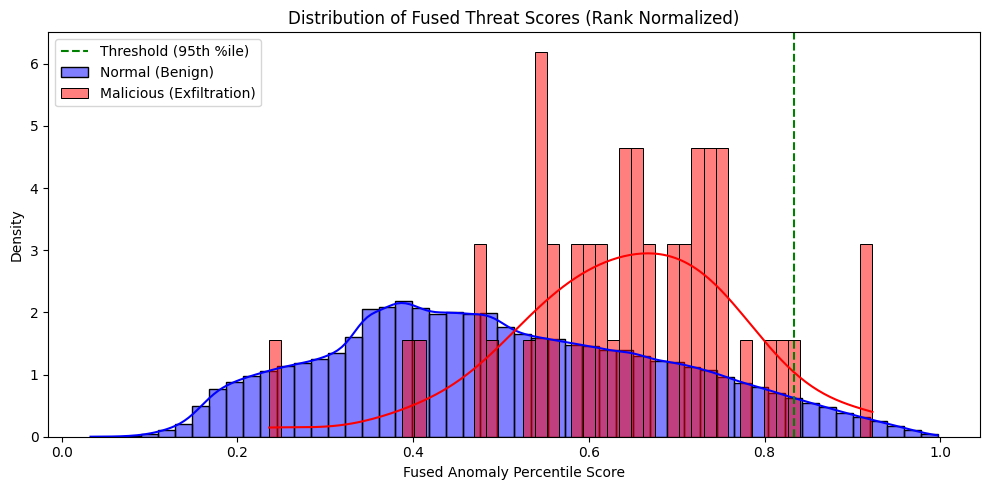

In [12]:
# ==========================================
# RESULTS & EVALUATION
# ==========================================
print("\n=== Multi-Agent System Classification Report ===")
print(classification_report(y_test, predictions))

print(f"ROC-AUC Score: {roc_auc_score(y_test, final_scores):.4f}")

# Plotting the Distributions
plt.figure(figsize=(10, 5))
sns.histplot(final_scores[y_test == 0], color='blue', label='Normal (Benign)',
             kde=True, stat="density", bins=50)
sns.histplot(final_scores[y_test == 1], color='red', label='Malicious (Exfiltration)',
             kde=True, stat="density", bins=50)
plt.axvline(threshold, color='green', linestyle='--', label="Threshold (95th %ile)")
plt.title("Distribution of Fused Threat Scores (Rank Normalized)")
plt.xlabel("Fused Anomaly Percentile Score")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()




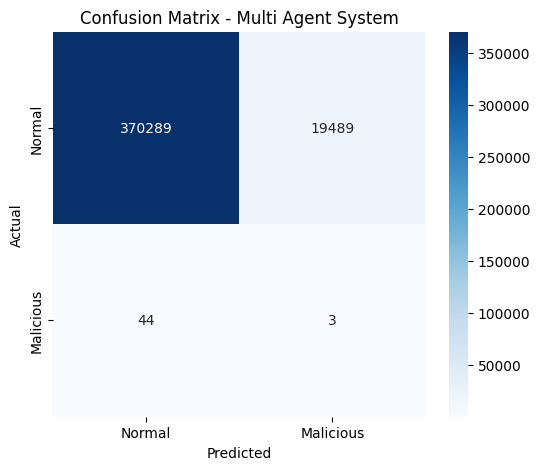

In [13]:
# ============================================================================
# Confusion Matrix
# ============================================================================
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Malicious'],
            yticklabels=['Normal', 'Malicious'])
plt.title("Confusion Matrix - Multi Agent System")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()




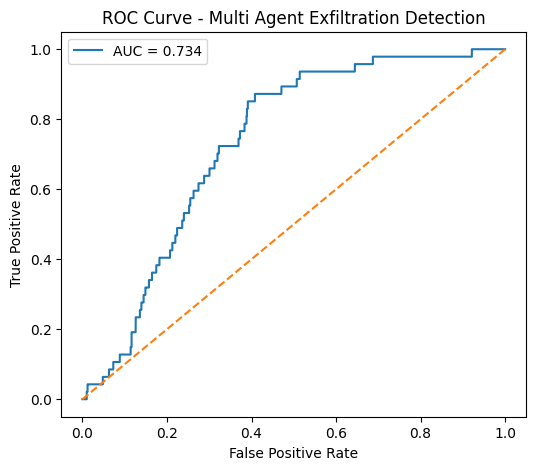

In [14]:
# ============================================================================
# ROC Curve
# ============================================================================
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, final_scores)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, final_scores):.3f}")
plt.plot([0, 1], [0, 1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Multi Agent Exfiltration Detection")
plt.legend()
plt.show()